# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [5]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [6]:
import zipfile
import glob
import os

# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_files = glob.glob(os.path.join(EXTRACT_DIR, '*.csv'))
csv_path = csv_files[0]  # Assuming there is only one CSV file
print(f"Using CSV file: {csv_path}")

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
print(df.info())
display(df.head())

# TODO: identify target column
target = 'heart disease'  # Changed from 'target' to 'heart disease'

# TODO: split features and target
X = df.drop(columns=[target])
y = df[target].apply(lambda x: 1 if x == 2 else 0) # Map 1 to 0 and 2 to 1 for binary classification

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Using CSV file: heart_ds/dataset_heart.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral                     270 non-null    int64  
 5   fasting blood sugar                   270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   max heart rate                        270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  ST segment                            270 n

,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


### Basic visual checks

Histograms for numeric features:


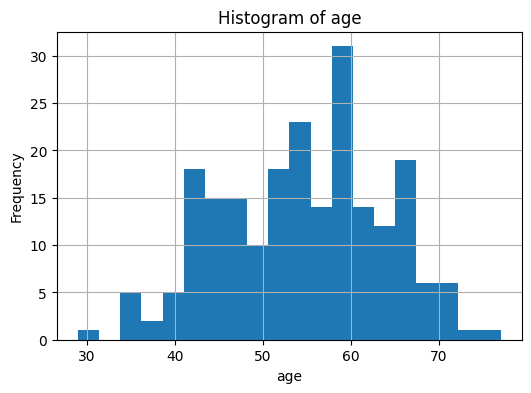

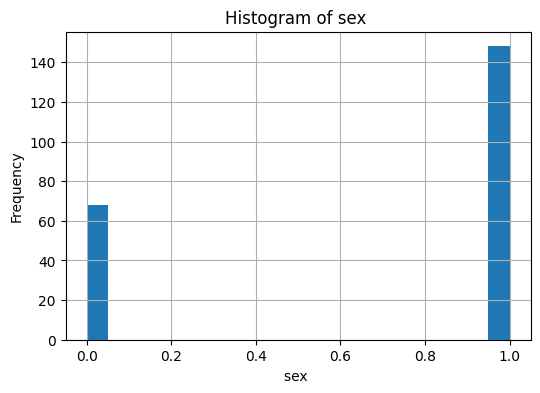

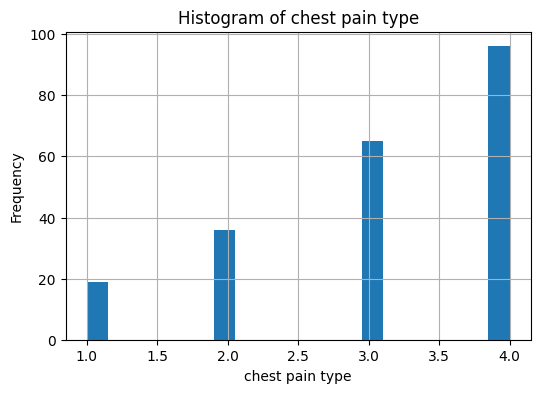

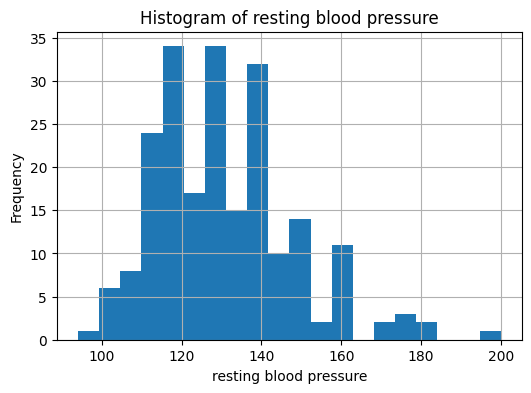

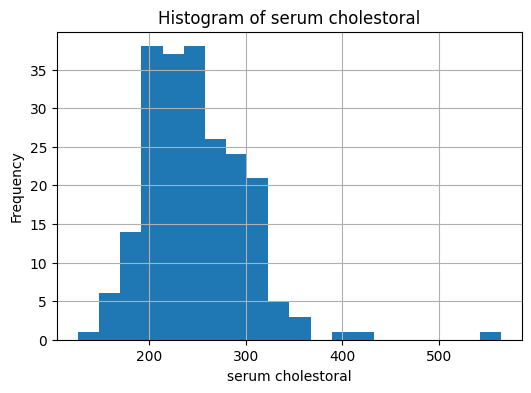

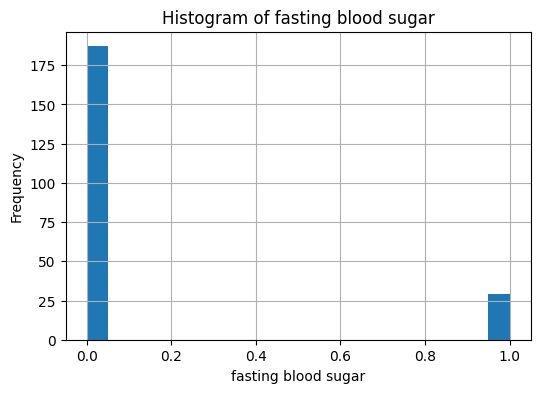

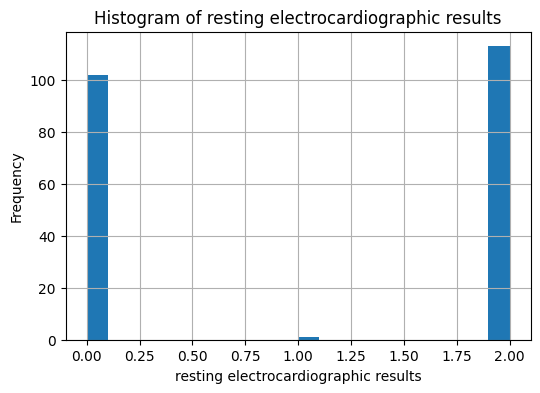

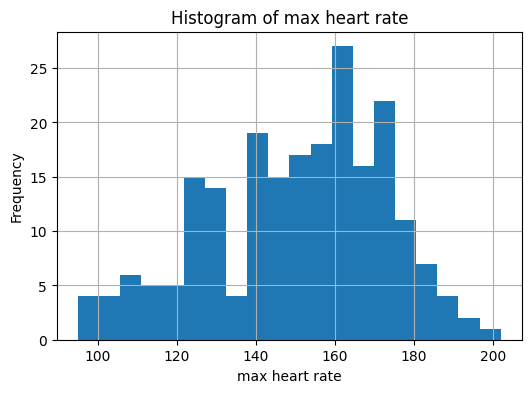

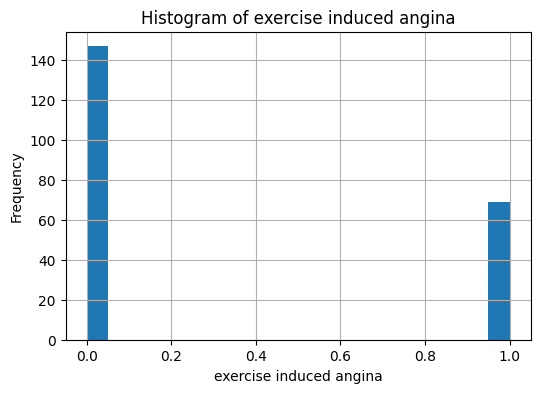

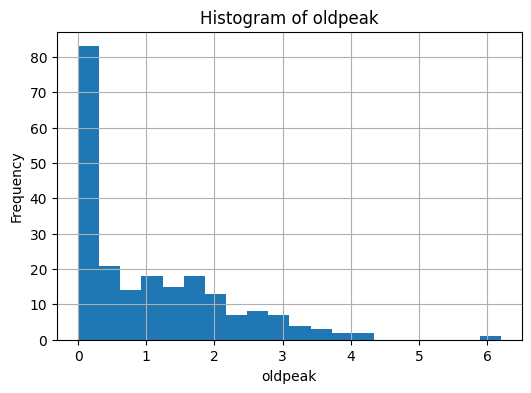

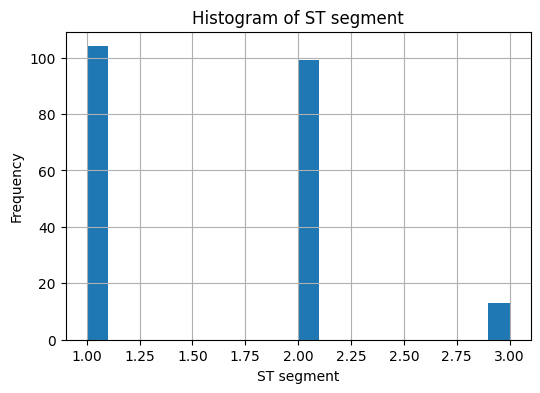

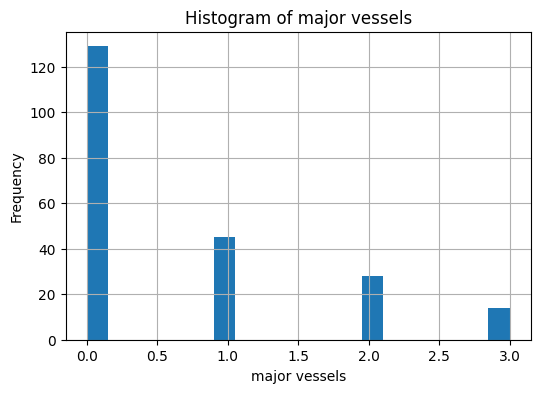

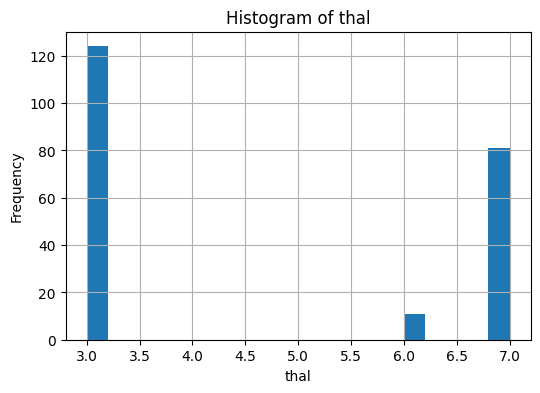


Class balance in target variable:


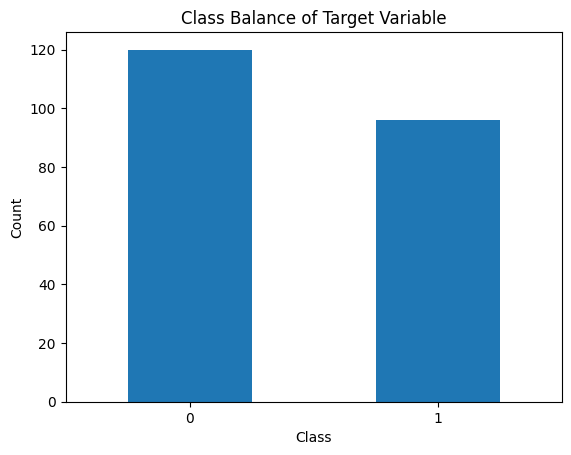

In [7]:
# TODO: pick a few numeric columns and plot histograms
print('Histograms for numeric features:')
for col in X_train.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6, 4))
    X_train[col].hist(bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# TODO: plot class balance as a bar chart
print('\nClass balance in target variable:')
y_train.value_counts().plot(kind='bar')
plt.title('Class Balance of Target Variable')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## Preprocessing pipeline

In [8]:
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns
num_cols = X_train.select_dtypes(include=np.number).columns

# TODO: build a ColumnTransformer named pre
# For numeric columns, use StandardScaler
# For categorical columns, use OneHotEncoder
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

## Helper - evaluation function

In [9]:
def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted'),
    }
    print(f"--- {name} ---")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")

    # TODO: confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_test)))
    plt.xticks(tick_marks, np.unique(y_test), rotation=45)
    plt.yticks(tick_marks, np.unique(y_test))
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1] # Assuming binary classification and positive class is 1
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)

        plt.figure(figsize=(6, 4))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Receiver Operating Characteristic for {name}')
        plt.legend(loc="lower right")
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- Logistic Regression (no GridSearch) ---
accuracy: 0.8519
precision: 0.8620
recall: 0.8519
f1: 0.8523


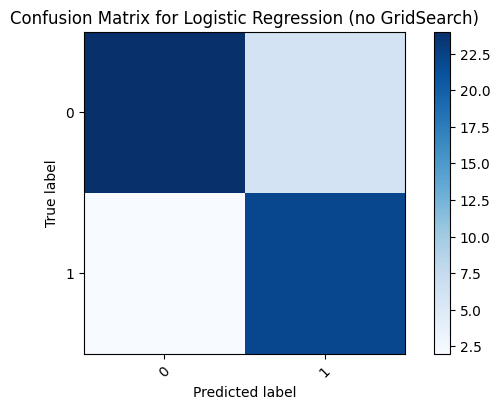

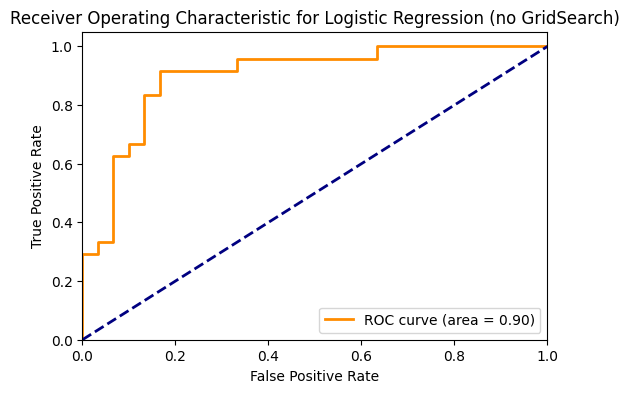

In [10]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(steps=[('preprocessor', pre),
                        ('lr', LogisticRegression(solver='liblinear', random_state=RANDOM_STATE, max_iter=1000))])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (no GridSearch)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **la

Best params: {'lr__C': 0.01, 'lr__penalty': 'l2'}
--- LR grid ---
accuracy: 0.8519
precision: 0.8519
recall: 0.8519
f1: 0.8519


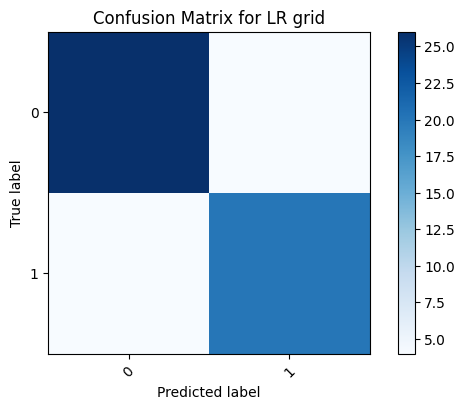

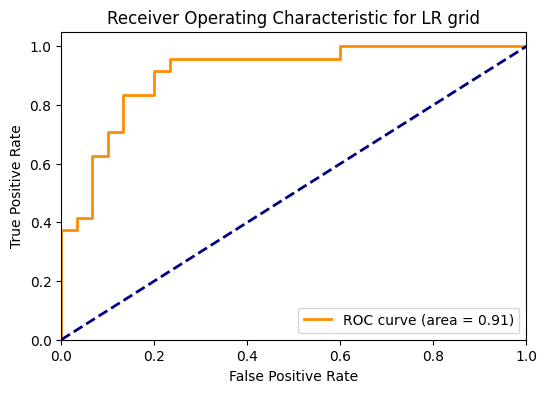

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


pipe_lr_cv = Pipeline(steps=[('preprocessor', pre),
                        ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))])

param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM no grid ---
accuracy: 0.8148
precision: 0.8181
recall: 0.8148
f1: 0.8153


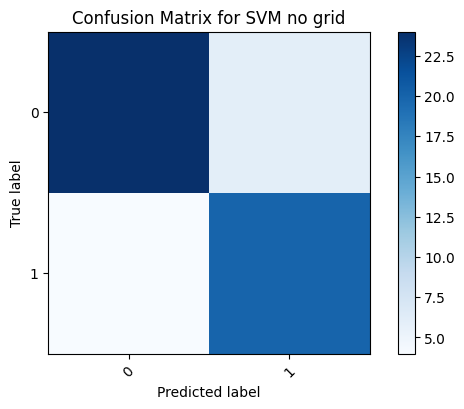

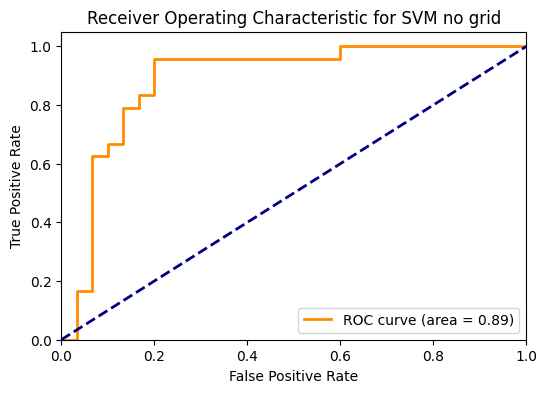

In [17]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE, probability=True)) # probability=True for ROC curve
])

pipe_svm.fit(X_train, y_train)
svm_no_gs_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

In [13]:
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(random_state=RANDOM_STATE, probability=True))
])

svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

In [14]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = None
# pipe_xgb.fit(...)
# xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test)


## Exercise 7 - XGBoost with Grid Search

In [15]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = None

# TODO: define a reasonable param_grid
xgb_param_grid = {
    # 'xgb__n_estimators': [...],
    # 'xgb__learning_rate': [...],
    # 'xgb__max_depth': [...],
    # 'xgb__subsample': [...],
    # 'xgb__colsample_bytree': [...],
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = None
# best_xgb = grid_xgb.best_estimator_
# xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test)


## Compare models

In [16]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary


{}